# Pre-lab 2: Vanilla Gaussian Processes and the Class GP Design: SOLUTION KEY
### ME 323 Module 1 (staff only)

<img src="https://raw.githubusercontent.com/andrewvoss8-boop/core-me-data-science-activities-public/main/me323/Module1_drafts/figures/I_beam_dimensions.jpg" alt="I-beam dimensions" width="240">

The equation beam from Pre-lab 1, `(b=1.25, H_web=13.4)`, was predicted at
46.6 N/g. The class query returned **483.0 N**, or **37.64 N/g on the same
estimated-mass basis**. It is the best of the first 15 beams, beating the
original best-of-14 value of 36.88 N/g. The returned ratio is
19.2% below the equation prediction.

This notebook uses only data-driven, vanilla GPs. You will compare reasonable
setup choices, separate epistemic uncertainty from observation noise, use MUI
and EI, and then apply one locked recipe so the class submits one common beam.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

# Fixed geometry (you choose b and H_web; everything else is set)
B, TH, L = 10.0, 18.0, 150.0     # flange width, total height, test span (mm)
LP = 172.0                        # printed length (mm); overhangs the 150 mm span
KMASS = 0.2045                    # g/mm^2: mass per unit cross-section area at 172 mm

# Handbook starting values — Pre-lab 1 calibrates the three marked ones
SY = 76e6                         # Pa, PLA strength                 (calibrated)
K_LTB = 0.33                      # fixture effective-length factor  (calibrated)
CS = 1.0                          # web shear-strength multiplier    (calibrated)
E, G = 2.5e9, 2.5e9 / 2.6         # Young's / shear modulus (Pa) — fixed
C1, C2 = 1.35, 0.55               # LTB moment-gradient / load-height factors
URL = ("https://raw.githubusercontent.com/andrewvoss8-boop/"
       "core-me-data-science-activities-public/main/data/student_beams_B10_L150.csv")
try:
    df = pd.read_csv(URL); print("loaded from GitHub")
except Exception:
    df = pd.read_csv("student_beams_B10_L150.csv"); print("loaded local copy")
df = df.rename(columns={"b_mm": "b", "H_web_mm": "H"})

def estimated_mass_g(b, H):
    A = b * H + B * (TH - H)      # cross-section area, mm^2
    return KMASS * A              # grams
df["mass_est_g"] = estimated_mass_g(df.b, df.H)
df["mass_delta_g"] = df.weight_g - df.mass_est_g
df["mass_delta_pct"] = 100*df.mass_delta_g/df.mass_est_g
print(len(df), "tested beams")

eq_beam = pd.DataFrame([dict(beam_id=15, b=1.25, H=13.4, strength_N=483.0,
                             weight_g=np.nan,
                             mass_est_g=estimated_mass_g(1.25, 13.4),
                             failure_note="class equation beam")])
df = pd.concat([df, eq_beam], ignore_index=True)
df["str_to_weight"] = df.strength_N / df.mass_est_g
initial_best = df.loc[df.beam_id <= 14, "str_to_weight"].max()
assert 37.64 > initial_best
print(f"{len(df)} beams; original best={initial_best:.2f} N/g; "
      f"equation beam=37.64 N/g, now ranked #1")
pd.set_option("display.max_colwidth", None)
print("\nObserved failure notes carried into the GP decision:")
print(df.loc[df.beam_id <= 14, ["beam_id", "b", "H", "failure_note"]]
      .to_string(index=False))

loaded from GitHub
14 tested beams
15 beams; original best=36.88 N/g; equation beam=37.64 N/g, now ranked #1

Observed failure notes carried into the GP decision:
 beam_id    b    H                                                                                                                            failure_note
       1 7.00 16.0                                                                                Complete vertical fracture across the center of the beam
       2 7.00 10.5                                                                                Complete vertical fracture across the center of the beam
       3 4.85 14.4                                                        Vertical fracture on the bottom of the beam, but not completely through the beam
       4 3.25 15.1                                                        Vertical fracture on the bottom of the beam, but not completely through the beam
       5 3.55  7.5                                            

## 1. What choices define a vanilla GP?

A surrogate maps `(b, H_web)` to a performance prediction without using the
failure equations. For a raw target, the GP mean is the central prediction.
For the official log target, `exp(mu_log)` is the posterior median in N/g, not
the arithmetic mean.

- Target: raw str/w or log str/w. Log space makes relative errors and
  multiplicative print scatter more natural.
- Input scale: raw millimeters or standardized coordinates. Scaling changes
  what one numerical unit of distance means to the kernel.
- Kernel: RBF assumes a very smooth response; Matérn-5/2 permits less smooth
  variation.
- Length scales: separate ARD scales let `b` and `H_web` vary independently, while
  one shared scale is more strongly regularized.
- `alpha`: assumed aleatory observation variance. It is not the GP's
  reducible epistemic uncertainty.

The comparisons below change one choice at a time. None uses physics features.

In [2]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF, Matern

X = df[["b", "H"]].values.astype(float)
sw_obs = df.str_to_weight.values.astype(float)
bg = np.linspace(1.25, 7.0, 60); Hg = np.linspace(5.0, 16.0, 60)
BB, HH = np.meshgrid(bg, Hg)
Xg = np.column_stack([BB.ravel(), HH.ravel()])

def fit_vanilla_option(target="log", scale=True, kernel_name="RBF",
                       ard=True, noise=0.03):
    fmu = X.mean(0) if scale else np.zeros(2)
    fsd = X.std(0) + 1e-12 if scale else np.ones(2)
    Xfit = (X-fmu)/fsd
    response = np.log(sw_obs) if target == "log" else sw_obs
    ymean = response.mean()
    length0 = [1.0, 1.0] if ard else 1.0
    bounds = (0.1, 30.0) if scale else (0.05, 50.0)
    base = RBF(length0, bounds) if kernel_name == "RBF" else Matern(
        length0, bounds, nu=2.5)
    kernel = C(1.0, (1e-3, 1e3))*base
    alpha = noise**2 if target == "log" else (noise*response.mean())**2
    gp_ = GaussianProcessRegressor(
        kernel, alpha=alpha, normalize_y=False,
        n_restarts_optimizer=5, random_state=0).fit(Xfit, response-ymean)
    return dict(gp=gp_, fmu=fmu, fsd=fsd, ymean=ymean, target=target,
                scale=scale, kernel_name=kernel_name, ard=ard, noise=noise)

def predict_option(model, Xq):
    mu, sd = model["gp"].predict(
        (np.asarray(Xq)-model["fmu"])/model["fsd"], return_std=True)
    centered = mu + model["ymean"]
    central_sw = np.exp(centered) if model["target"] == "log" else centered
    return central_sw, sd

def physical_length_scales(model):
    ls = np.atleast_1d(model["gp"].kernel_.k2.length_scale).astype(float)
    if ls.size == 1:
        ls = np.repeat(ls, 2)
    return ls*model["fsd"] if model["scale"] else ls

OPTION_SPECS = [
    ("official: log, scaled, RBF, ARD", dict()),
    ("raw target only", dict(target="raw")),
    ("unscaled inputs only", dict(scale=False)),
    ("Matern-5/2 only", dict(kernel_name="Matern")),
    ("shared scale only", dict(ard=False)),
]
option_models = [(name, fit_vanilla_option(**kw)) for name, kw in OPTION_SPECS]
for name, model in option_models:
    print(f"{name}\n  {model['gp'].kernel_}\n"
          f"  physical length scales [b,H] = {physical_length_scales(model).round(3)} mm")


official: log, scaled, RBF, ARD
  0.0799**2 * RBF(length_scale=[1.79, 0.129])
  physical length scales [b,H] = [3.44 0.44] mm
raw target only
  2.59**2 * RBF(length_scale=[1.68, 0.121])
  physical length scales [b,H] = [3.218 0.414] mm
unscaled inputs only
  0.0799**2 * RBF(length_scale=[3.44, 0.44])
  physical length scales [b,H] = [3.44 0.44] mm
Matern-5/2 only
  0.0811**2 * Matern(length_scale=[2.15, 0.153], nu=2.5)
  physical length scales [b,H] = [4.119 0.522] mm
shared scale only
  0.0801**2 * RBF(length_scale=0.4)
  physical length scales [b,H] = [0.767 1.363] mm


## 2. Compare setup choices on the same axes

These are not five independent truths. They are five posterior surfaces from
the same 15 observations under different modeling assumptions.

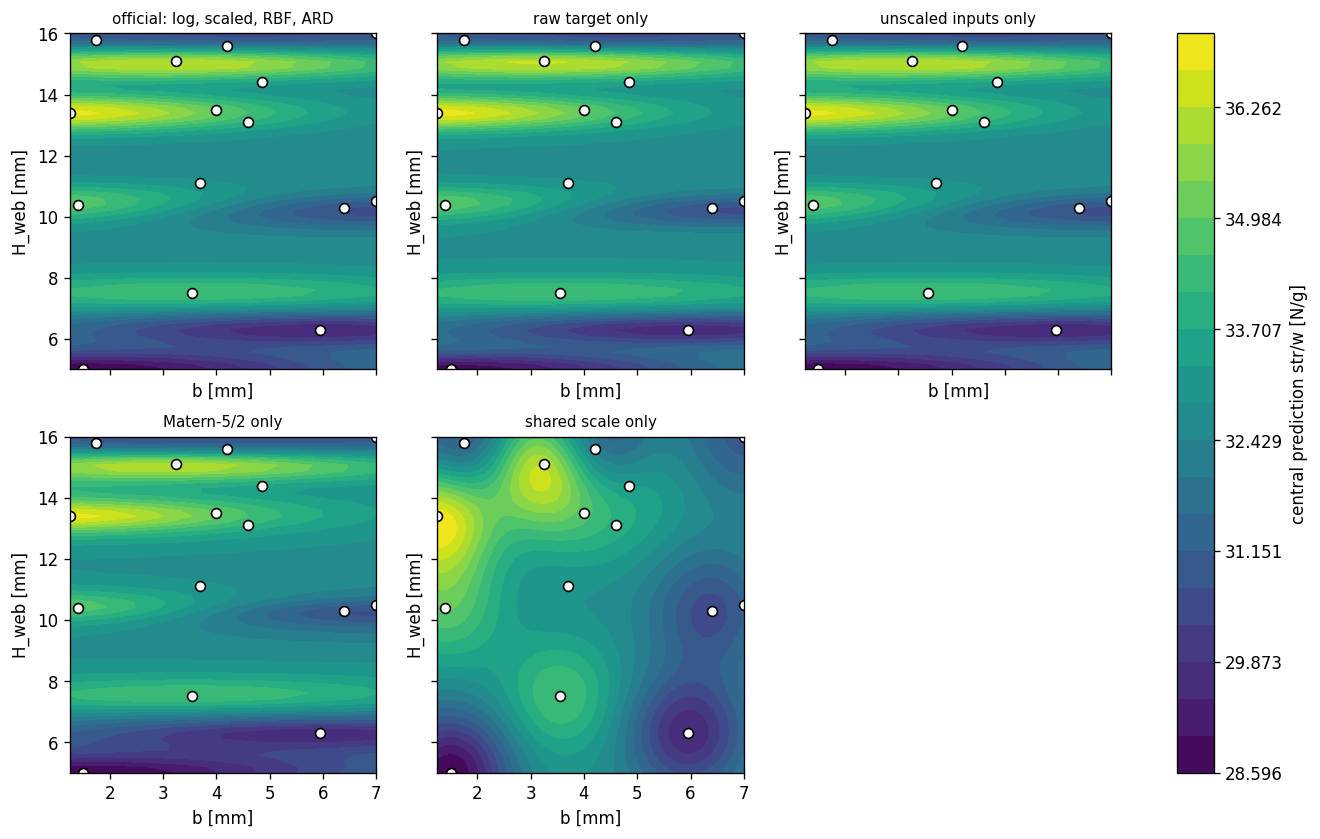

In [3]:
option_means = [predict_option(model, Xg)[0].reshape(BB.shape)
                for _, model in option_models]
vmin = min(z.min() for z in option_means); vmax = max(z.max() for z in option_means)
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
for ax, (name, _), Z in zip(axes.flat, option_models, option_means):
    cf = ax.contourf(BB, HH, Z, levels=np.linspace(vmin, vmax, 21),
                     vmin=vmin, vmax=vmax)
    ax.scatter(df.b, df.H, c="white", edgecolor="black", s=35)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("b [mm]"); ax.set_ylabel("H_web [mm]")
axes.flat[-1].axis("off")
fig.colorbar(cf, ax=axes.ravel().tolist(), label="central prediction str/w [N/g]")
plt.show()

## 3. Lock the class predictive model

From here onward, reset to the official recipe: standardized `(b,H_web)`, centered
log str/w, RBF with separate length scales, 3% relative noise, fixed optimizer
seed. This keeps the class result reproducible.

fitted official kernel: 0.0799**2 * RBF(length_scale=[1.79, 0.129])
physical length scales: b=3.44 mm, H_web=0.44 mm
checkpoint kernel: roughly 0.0799**2 * RBF(length_scale=[1.79, 0.129])


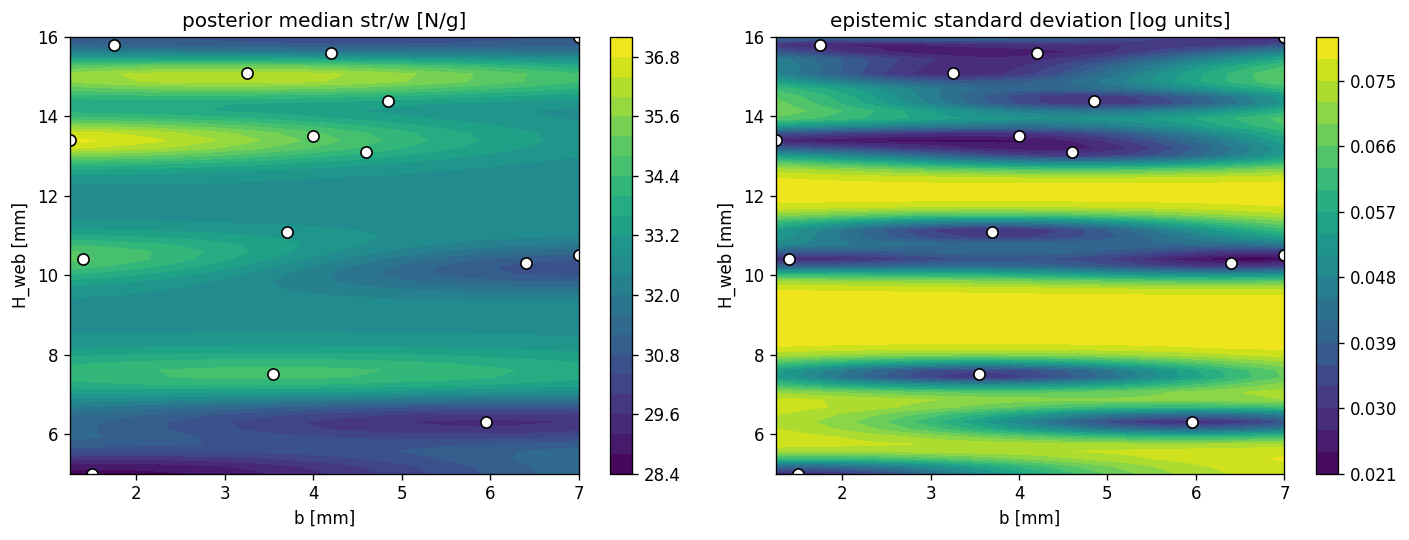

In [4]:
fmu, fsd = X.mean(0), X.std(0) + 1e-12
y = np.log(sw_obs); ymean = y.mean()
def official_kernel():
    return C(1.0, (1e-3, 1e3))*RBF([1.0, 1.0], (1e-1, 30.0))
kernel = official_kernel()
gp = GaussianProcessRegressor(
    kernel, alpha=0.03**2, normalize_y=False,
    n_restarts_optimizer=5, random_state=0).fit((X-fmu)/fsd, y-ymean)
mu_c, std = gp.predict((Xg-fmu)/fsd, return_std=True)
MU = np.exp(mu_c+ymean).reshape(BB.shape)
STD = std.reshape(BB.shape)
ls_std = np.asarray(gp.kernel_.k2.length_scale, float)
ls_mm = ls_std*fsd
print("fitted official kernel:", gp.kernel_)
print(f"physical length scales: b={ls_mm[0]:.2f} mm, H_web={ls_mm[1]:.2f} mm")
print("checkpoint kernel: roughly 0.0799**2 * RBF(length_scale=[1.79, 0.129])")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
for a, Z, title in [(ax[0], MU, "posterior median str/w [N/g]"),
                    (ax[1], STD, "epistemic standard deviation [log units]")]:
    cf = a.contourf(BB, HH, Z, levels=20); fig.colorbar(cf, ax=a)
    a.scatter(df.b, df.H, c="white", edgecolor="black", s=45)
    a.set_xlabel("b [mm]"); a.set_ylabel("H_web [mm]"); a.set_title(title)
plt.tight_layout(); plt.show()

The fitted length scale is much longer in `b` than in `H_web`, so the surface
changes mostly with `H_web`. That is an ARD identifiability result from 15 sparse
points, not a plotting-grid bug and not proof that `b` is physically irrelevant.

### Read the 2D posterior through two 1D slices

Let $f(b,H)=\ln(S/W)$ be the latent log strength-to-weight trend. The GP gives

$$f(\mathbf{x})\mid\mathcal D\sim
\mathcal N\!\left(\mu_f(\mathbf{x}),\sigma_{epi}^2(\mathbf{x})\right).$$

Epistemic uncertainty describes uncertainty about that latent trend and can
shrink when informative tests are added. A future printed and tested beam also
has independent observation scatter $\epsilon\sim\mathcal N(0,r^2)$:

$$y_*=f(\mathbf{x})+\epsilon,\qquad
\sigma_{total}=\sqrt{\sigma_{epi}^2+r^2},\quad r=0.03.$$

The two cuts below cross at the measured equation beam. The inner band is
uncertainty about the latent trend; the outer band predicts one future
observation. Both are conditional on the kernel, noise, and model form.

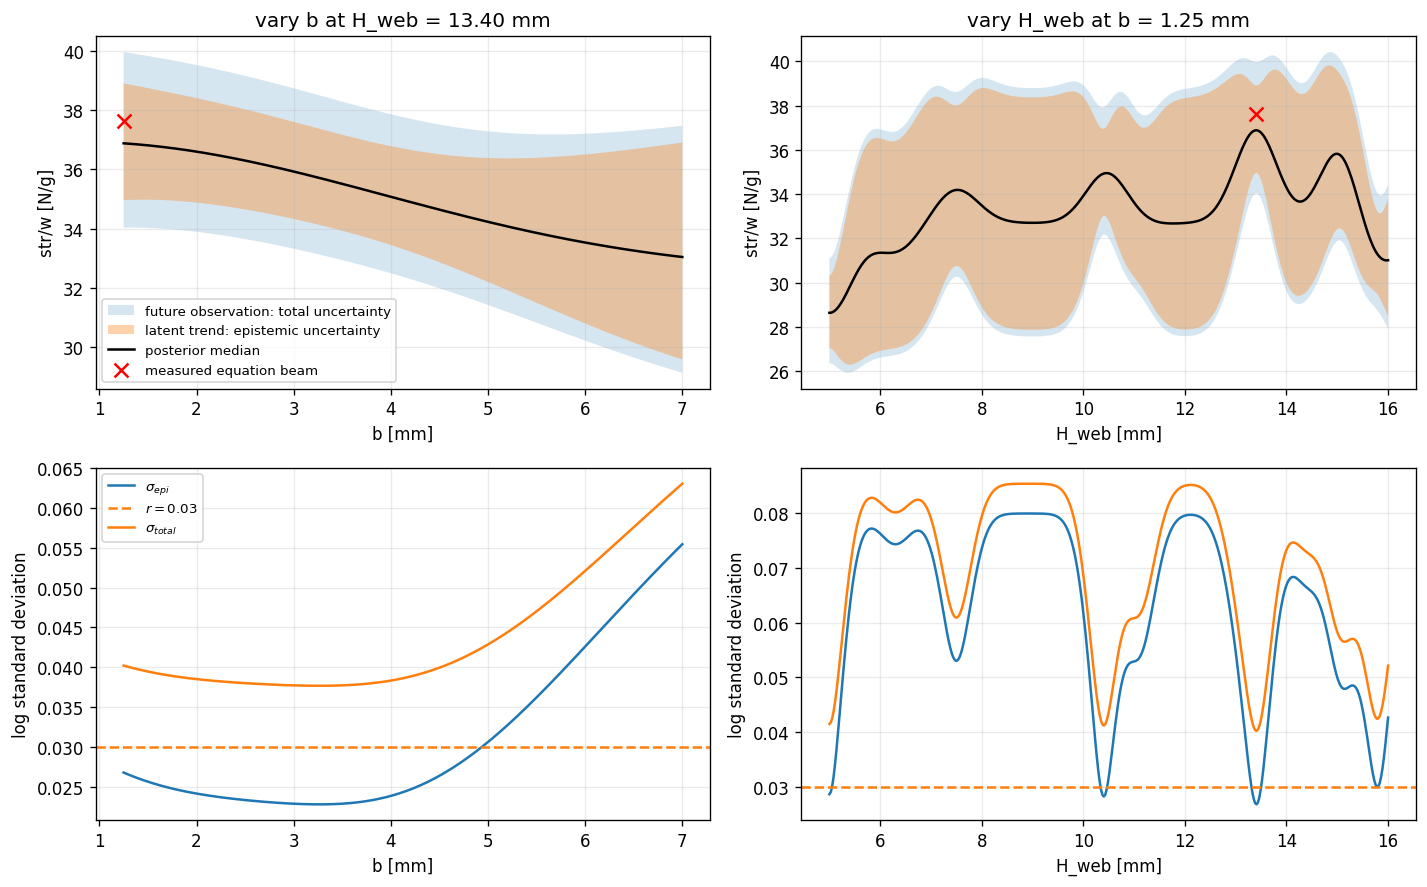

slice crossing: median=36.88 N/g, sigma_epi=0.0268, r=0.0300, sigma_total=0.0402


In [5]:
r_log, z_band = 0.03, 2.0
b_slice = np.linspace(1.25, 7.0, 400)
H_slice = np.linspace(5.0, 16.0, 400)
slices = [
    ("vary b at H_web = 13.40 mm", b_slice,
     np.column_stack([b_slice, np.full_like(b_slice, 13.40)]),
     "b [mm]", 1.25),
    ("vary H_web at b = 1.25 mm", H_slice,
     np.column_stack([np.full_like(H_slice, 1.25), H_slice]),
     "H_web [mm]", 13.40),
]
equation_sw = float(df.loc[df.beam_id.eq(15), "str_to_weight"].iloc[0])
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))
for col, (title, xplot, Xslice, xlabel, x_anchor) in enumerate(slices):
    mu_slice, sigma_epi = gp.predict((Xslice-fmu)/fsd, return_std=True)
    mu_log = mu_slice + ymean
    median_sw = np.exp(mu_log)
    sigma_total = np.sqrt(sigma_epi**2 + r_log**2)
    lo_epi, hi_epi = (np.exp(mu_log-z_band*sigma_epi),
                      np.exp(mu_log+z_band*sigma_epi))
    lo_total, hi_total = (np.exp(mu_log-z_band*sigma_total),
                          np.exp(mu_log+z_band*sigma_total))
    ax = axes[0, col]
    ax.fill_between(xplot, lo_total, hi_total, alpha=0.18,
                    label="future observation: total uncertainty")
    ax.fill_between(xplot, lo_epi, hi_epi, alpha=0.35,
                    label="latent trend: epistemic uncertainty")
    ax.plot(xplot, median_sw, color="black", label="posterior median")
    ax.scatter(x_anchor, equation_sw, color="red", marker="x", s=70,
               label="measured equation beam")
    ax.set(title=title, xlabel=xlabel, ylabel="str/w [N/g]")
    ax.grid(alpha=0.25)
    ax = axes[1, col]
    ax.plot(xplot, sigma_epi, label=r"$\sigma_{epi}$")
    ax.axhline(r_log, color="tab:orange", linestyle="--", label=r"$r=0.03$")
    ax.plot(xplot, sigma_total, label=r"$\sigma_{total}$")
    ax.set(xlabel=xlabel, ylabel="log standard deviation")
    ax.grid(alpha=0.25)
axes[0, 0].legend(fontsize=8)
axes[1, 0].legend(fontsize=8)
plt.tight_layout(); plt.show()

cross = np.array([[1.25, 13.40]])
cross_mu, cross_epi = gp.predict((cross-fmu)/fsd, return_std=True)
cross_total = np.sqrt(cross_epi[0]**2 + r_log**2)
print(f"slice crossing: median={np.exp(cross_mu[0]+ymean):.2f} N/g, "
      f"sigma_epi={cross_epi[0]:.4f}, r={r_log:.4f}, "
      f"sigma_total={cross_total:.4f}")

## 4. Noise: aleatory versus epistemic uncertainty

Refit at 1%, 3%, and 10% assumed relative observation noise. The latent GP
standard deviation is epistemic and can shrink with more informative tests.
Total predictive uncertainty also includes the assumed observation noise:
$\sigma_{total}=\sqrt{\sigma_{epi}^2+r^2}$ in log space.

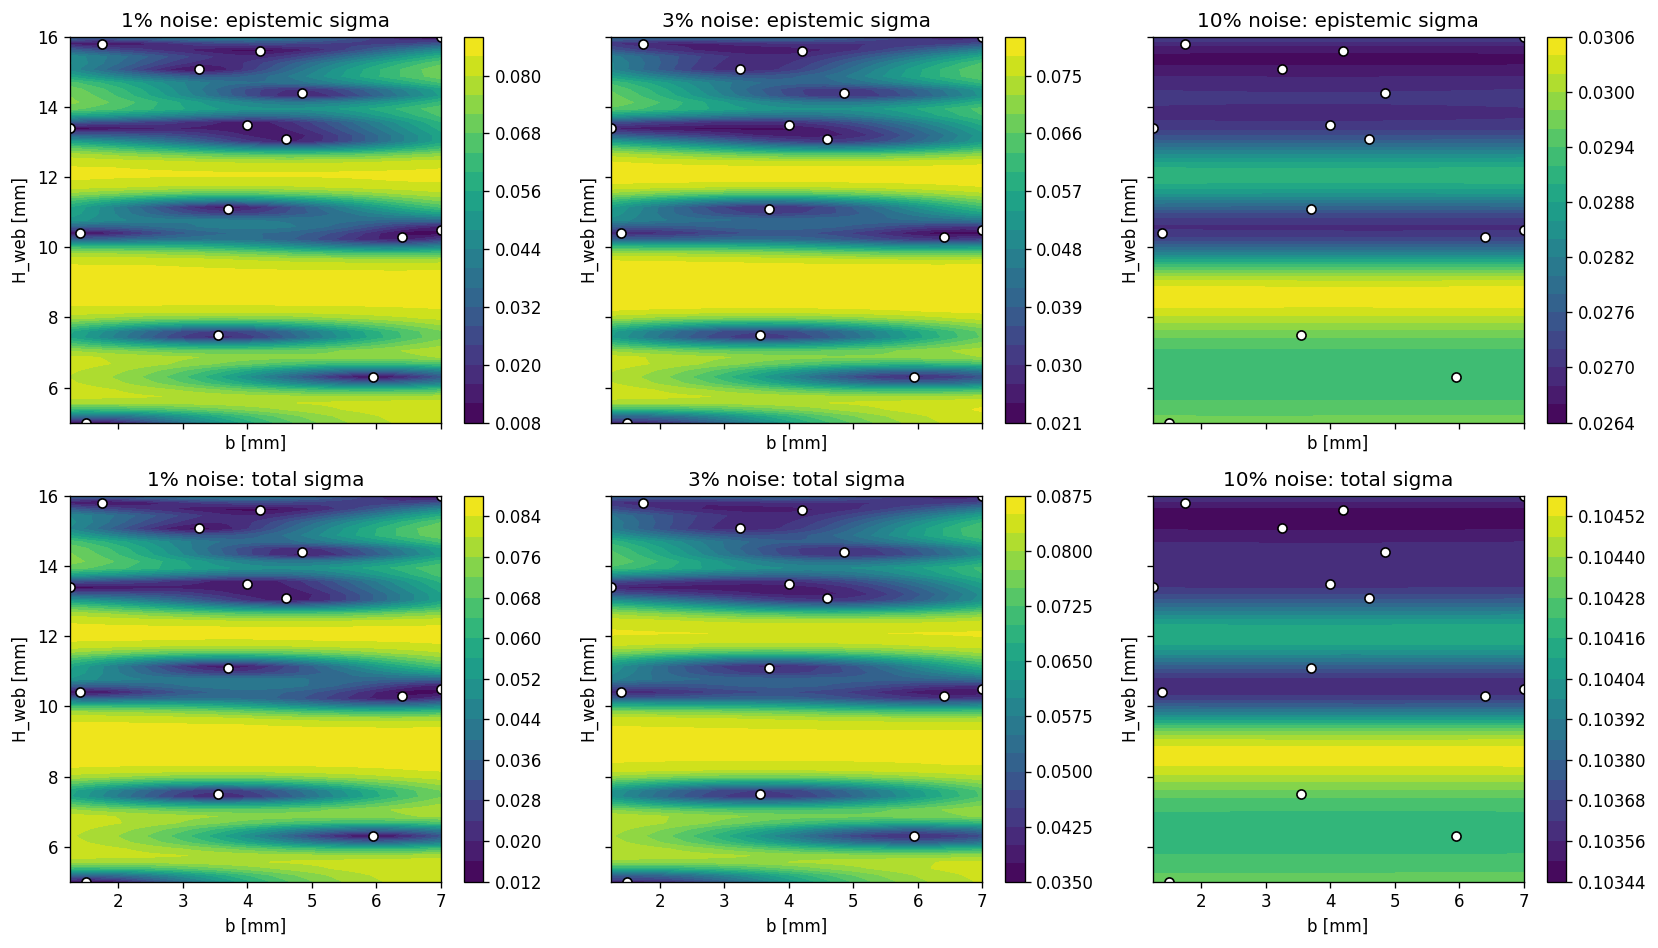

 noise_pct     b  H_web  median_sw  sigma_epistemic  sigma_total
         1 1.640 14.881     36.373            0.049        0.050
         3 1.445 13.390     36.828            0.026        0.040
        10 1.445 13.576     33.392            0.027        0.104

CHECKPOINT: the recommendation moves as the assumed noise grows: 1% -> (1.64, 14.88);  3% -> (1.44, 13.39);  10% -> (1.44, 13.58)


In [6]:
tested_excl = np.zeros(len(Xg), bool)
for _b, _H in X:
    tested_excl |= (np.abs(Xg[:, 0]-_b) < 0.15) & (np.abs(Xg[:, 1]-_H) < 0.30)

noise_fits, noise_rows = {}, []
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
for col, pct in enumerate([1, 3, 10]):
    r = pct/100
    g2 = GaussianProcessRegressor(
        official_kernel(), alpha=r**2, normalize_y=False,
        n_restarts_optimizer=5, random_state=0).fit((X-fmu)/fsd, y-ymean)
    m2, s2 = g2.predict((Xg-fmu)/fsd, return_std=True)
    total2 = np.sqrt(s2**2+r**2)
    noise_fits[pct] = (g2, m2, s2)
    i = int(np.argmax(np.where(tested_excl, -np.inf, m2+s2)))
    noise_rows.append(dict(noise_pct=pct, b=Xg[i,0], H_web=Xg[i,1],
                           median_sw=np.exp(m2[i]+ymean),
                           sigma_epistemic=s2[i], sigma_total=total2[i]))
    for row, (Z, label) in enumerate([(s2, "epistemic"), (total2, "total")]):
        cf = axes[row, col].contourf(BB, HH, Z.reshape(BB.shape), levels=20)
        axes[row, col].scatter(df.b, df.H, c="white", edgecolor="black", s=30)
        axes[row, col].set_title(f"{pct}% noise: {label} sigma")
        axes[row, col].set_xlabel("b [mm]")
        axes[row, col].set_ylabel("H_web [mm]")
        fig.colorbar(cf, ax=axes[row, col])
plt.tight_layout(); plt.show()
print(pd.DataFrame(noise_rows).round(3).to_string(index=False))
print("\nCHECKPOINT: the recommendation moves as the assumed noise grows: 1% -> (1.64, 14.88);  3% -> (1.44, 13.39);  10% -> (1.44, 13.58)")

A noise value can be a physical repeatability estimate and a regularization
assumption. If the recommendation moves, the action is model-assumption
sensitive. If it does not, that one decision is locally robust; the noise value
is not thereby proven correct.

## 5. MUI and Expected Improvement in the full 2D design box

Maximum Upper Interval uses $a=\mu+\psi\sigma$. Expected Improvement uses

$$EI=(\mu-y_{best}-\xi)\Phi(Z)+\sigma\phi(Z),\quad
Z=\frac{\mu-y_{best}-\xi}{\sigma}.$$

Both operate in centered log-str/w space here, and both exclude already-tested
designs with the same rule. Fill in one line in each function.

In [7]:
from scipy.stats import norm

def mui(mu, sigma, psi):
    return mu + psi*sigma

y_best = np.log(df.str_to_weight).max()-ymean
def ei(mu, sigma, xi=0.0):
    imp = mu - y_best - xi
    safe = np.maximum(sigma, 1e-12)
    Z = imp/safe
    return np.where(sigma > 1e-12,
                    imp*norm.cdf(Z)+sigma*norm.pdf(Z), 0.0)

def recommend_mui(psi, mu=mu_c, sigma=std):
    acq = np.where(tested_excl, -np.inf, mui(mu, sigma, psi))
    i = int(np.argmax(acq))
    return Xg[i], np.exp(mu[i]+ymean), sigma[i], acq[i]

def recommend_ei(xi, mu=mu_c, sigma=std):
    acq = np.where(tested_excl, -np.inf, ei(mu, sigma, xi))
    i = int(np.argmax(acq))
    return Xg[i], np.exp(mu[i]+ymean), sigma[i], acq[i]

rows = []
for psi in [0.0, 0.5, 1.0, 2.0, 3.0]:
    x, median, sig, acq = recommend_mui(psi)
    rows.append(dict(method="MUI", dial=psi, b=x[0], H_web=x[1],
                     median_sw=median, sigma_epi=sig, acquisition=acq))
for xi in [0.0, 0.005, 0.01, 0.03, 0.05]:
    x, median, sig, acq = recommend_ei(xi)
    rows.append(dict(method="EI", dial=xi, b=x[0], H_web=x[1],
                     median_sw=median, sigma_epi=sig, acquisition=acq))
acq_table = pd.DataFrame(rows)
print(acq_table.round(3).to_string(index=False))

method  dial     b  H_web  median_sw  sigma_epi  acquisition
   MUI 0.000 1.445 13.390     36.828      0.026        0.119
   MUI 0.500 1.445 13.390     36.828      0.026        0.132
   MUI 1.000 1.445 13.390     36.828      0.026        0.145
   MUI 2.000 1.250 14.881     35.678      0.055        0.197
   MUI 3.000 1.250 14.695     34.966      0.062        0.254
    EI 0.000 1.250 14.881     35.678      0.055        0.005
    EI 0.005 1.250 14.881     35.678      0.055        0.004
    EI 0.010 1.250 14.881     35.678      0.055        0.003
    EI 0.030 1.250 14.881     35.678      0.055        0.001
    EI 0.050 1.250 14.881     35.678      0.055        0.001


## 6. See what each acquisition rule values

The predictive model is identical in both panels. Only the acquisition rule
changes.

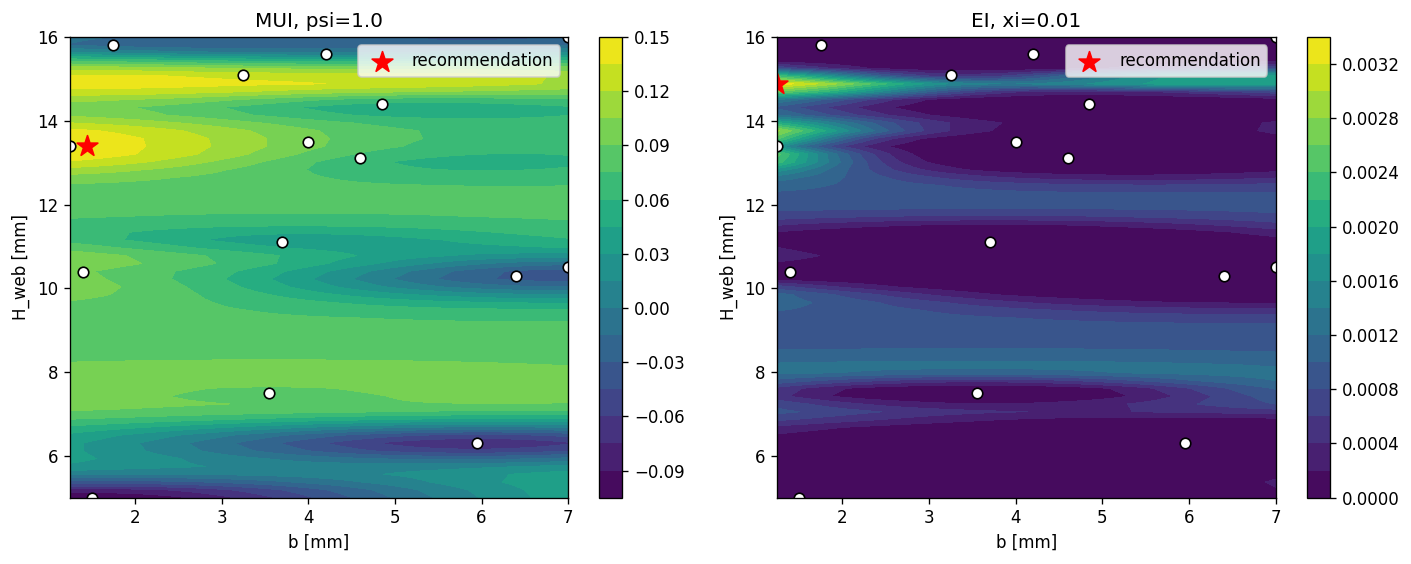

MUI psi=1: b=1.44, H_web=13.39
EI xi=.01: b=1.25, H_web=14.88
EI checkpoint: b=1.25, H_web=14.88.


In [8]:
psi_show, xi_show = 1.0, 0.01
mui_surface = mui(mu_c, std, psi_show).reshape(BB.shape)
ei_surface = ei(mu_c, std, xi_show).reshape(BB.shape)
x_mui, _, _, _ = recommend_mui(psi_show)
x_ei, _, _, _ = recommend_ei(xi_show)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, Z, title, xrec in [
    (axes[0], mui_surface, f"MUI, psi={psi_show}", x_mui),
    (axes[1], ei_surface, f"EI, xi={xi_show}", x_ei)]:
    cf = ax.contourf(BB, HH, Z, levels=20); fig.colorbar(cf, ax=ax)
    ax.scatter(df.b, df.H, c="white", edgecolor="black", s=40)
    ax.scatter(*xrec, c="red", marker="*", s=170, label="recommendation")
    ax.set_xlabel("b [mm]"); ax.set_ylabel("H_web [mm]")
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()
print(f"MUI psi=1: b={x_mui[0]:.2f}, H_web={x_mui[1]:.2f}")
print(f"EI xi=.01: b={x_ei[0]:.2f}, H_web={x_ei[1]:.2f}")
print("EI checkpoint: b=1.25, H_web=14.88.")

## 7. Final filter: the one class GP design

You explored alternatives, but the class query must be reproducible. The final
rule is fixed: official ARD-RBF model, 3% noise, MUI with $\psi=1$, the stated
grid, and the tested-point exclusion rule.

In [9]:
x_class, mean_class, sigma_class, _ = recommend_mui(1.0)
print(f"LOCKED CLASS DESIGN: b={x_class[0]:.2f} mm, H_web={x_class[1]:.2f} mm")
print(f"posterior median={mean_class:.1f} N/g, epistemic sigma_log={sigma_class:.3f}")
print("CHECKPOINT: b=1.44, H_web=13.39, predicted 36.8 N/g.")

LOCKED CLASS DESIGN: b=1.44 mm, H_web=13.39 mm
posterior median=36.8 N/g, epistemic sigma_log=0.026
CHECKPOINT: b=1.44, H_web=13.39, predicted 36.8 N/g.


In [10]:
assert abs(x_class[0]-1.44) < 0.06
assert abs(x_class[1]-13.39) < 0.06

## KEY-only sensitivity comparison

The official model remains the class rule. The next cell only shows what
regularizing the sparse length-scale problem would change.

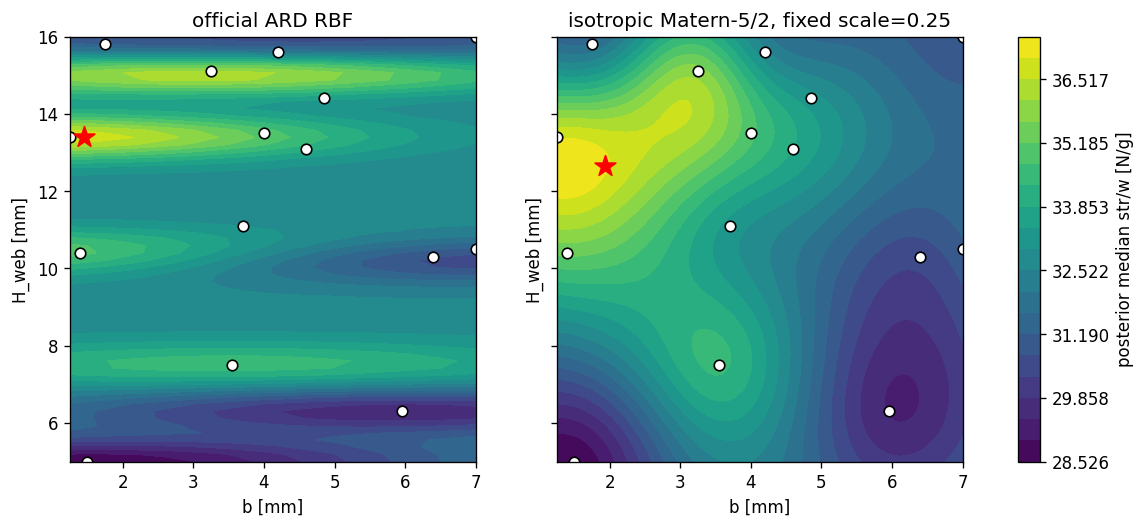

official MUI psi=1 recommendation: (1.44, 13.39)
regularized Matern recommendation: (1.93, 12.64)
This comparison changes kernel and length-scale regularization; it is not the class recommendation.


In [11]:
matern_fixed = GaussianProcessRegressor(
    C(1.0, (1e-3, 1e3))*Matern(
        length_scale=0.25, length_scale_bounds="fixed", nu=2.5),
    alpha=0.03**2, normalize_y=False,
    n_restarts_optimizer=5, random_state=0).fit(
        (X-np.array([1.25, 5.0]))/np.array([5.75, 11.0]), y-ymean)
mm, ss = matern_fixed.predict(
    (Xg-np.array([1.25, 5.0]))/np.array([5.75, 11.0]), return_std=True)
surfaces = [MU, np.exp(mm+ymean).reshape(BB.shape)]
im = int(np.argmax(np.where(tested_excl, -np.inf, mm+ss)))
x_matern = Xg[im]
lo = min(z.min() for z in surfaces); hi = max(z.max() for z in surfaces)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True, sharey=True)
for ax, Z, title, xrec in zip(
        axes, surfaces,
        ["official ARD RBF", "isotropic Matern-5/2, fixed scale=0.25"],
        [x_class, x_matern]):
    cf = ax.contourf(BB, HH, Z, levels=np.linspace(lo, hi, 21), vmin=lo, vmax=hi)
    ax.scatter(df.b, df.H, c="white", edgecolor="black", s=40)
    ax.scatter(*xrec, c="red", marker="*", s=170)
    ax.set_xlabel("b [mm]"); ax.set_ylabel("H_web [mm]"); ax.set_title(title)
fig.colorbar(cf, ax=axes.ravel().tolist(), label="posterior median str/w [N/g]")
plt.show()
print(f"official MUI psi=1 recommendation: {tuple(np.round(x_class, 2))}")
print(f"regularized Matern recommendation: {tuple(np.round(x_matern, 2))}")
print("This comparison changes kernel and length-scale regularization; it is not the class recommendation.")

## Memo questions

1. Cite one region where epistemic uncertainty changes the action relative to
   maximizing the posterior median alone. Use the median, epistemic-sigma, and
   acquisition maps.
2. Compare at least two vanilla setup choices from section 2. Which assumption
   changed the surface, and why is that not evidence that one is automatically true?
3. Compare MUI and EI. Do they recommend the same design, and what does each dial value?
4. Why does the locked GP design differ from the equation design? What do the
   failure notes contain that neither scalar-response model uses?
5. Explain whether the noise activity makes the locked recommendation robust
   or assumption-sensitive.

No new design code is required. The final submitted class design is
`(b=1.44, H_web=13.39)` from the locked cell.

## KEY: memo targets

1. Accept any map-supported region where a larger epistemic sigma changes the
   acquisition ranking relative to median-only exploitation.
2. Students should identify the one changed assumption and use the printed
   kernels/length scales or common-scale maps as evidence. Sparse-data MLE can
   support materially different surfaces.
3. MUI adds a sigma bonus everywhere; EI weights the probability and amount of
   beating the incumbent. The recommendation table supplies exact comparisons.
4. The equation maximizes its calibrated capacity/mass. The locked GP maximizes
   a data-conditioned upper interval. Failure morphology, layer separation,
   fixture tipping, and fracture progression are absent from both scalar targets.
5. Use the generated 1/3/10% table. Stability of one recommendation is local
   robustness, not validation of the assumed noise or kernel.